In [ ]:
# Claude LLM thread: https://claude.ai/project/7c3fc09a-a08a-4848-b9a5-7976327bf36d

In [12]:
pip install stable_baselines3

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\nikhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback

In [14]:
# Create directories for logs and models
log_dir = "logs/"
model_dir = "models/"
os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

In [15]:


def prepare_stock_data(file_path, min_data_points=60):
    """
    Prepare stock data from Excel/CSV file for risk analysis and portfolio management

    Args:
        file_path (str): Path to the Excel/CSV file
        min_data_points (int): Minimum number of data points required per stock

    Returns:
        dict: Dictionary of DataFrames with processed data for each stock
    """
    # Determine file type and read accordingly
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df = pd.read_excel(file_path)
    else:  # Assume CSV
        df = pd.read_csv(file_path)

    print(f"Original data shape: {df.shape}")
    print(f"Available columns: {df.columns.tolist()}")

    # Convert date to datetime if not already
    if 'date' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])

    # Ensure we have the required columns
    required_columns = ['date', 'close', 'tic']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in data")

    # Sort by ticker and date
    df = df.sort_values(['tic', 'date'])

    # Calculate additional features for risk assessment
    stock_dfs = {}
    skipped_stocks = 0
    processed_stocks = 0

    # Process each stock separately
    unique_tickers = df['tic'].unique()
    print(f"Found {len(unique_tickers)} unique tickers in the data")

    # For testing purposes, limit to first 20 stocks if there are too many
    if len(unique_tickers) > 1631:
        test_tickers = unique_tickers[:1631]
        print(f"Using first 20 tickers for testing: {test_tickers}")
    else:
        test_tickers = unique_tickers

    for ticker in test_tickers:
        stock_data = df[df['tic'] == ticker].copy()

        # Ensure we have enough data
        if len(stock_data) < min_data_points:
            print(f"Skipping {ticker} - insufficient data ({len(stock_data)} rows)")
            skipped_stocks += 1
            continue

        # Calculate daily returns
        stock_data['daily_return'] = stock_data['close'].pct_change()

        # Calculate volatility (20-day and 60-day)
        stock_data['volatility_20d'] = stock_data['daily_return'].rolling(window=20).std() * np.sqrt(252)
        stock_data['volatility_60d'] = stock_data['daily_return'].rolling(window=60).std() * np.sqrt(252)

        # Calculate drawdowns
        stock_data['cumulative_return'] = (1 + stock_data['daily_return']).cumprod()
        stock_data['rolling_max'] = stock_data['cumulative_return'].cummax()
        stock_data['drawdown'] = (stock_data['cumulative_return'] / stock_data['rolling_max']) - 1
        stock_data['max_drawdown_60d'] = stock_data['drawdown'].rolling(window=60).min()

        # Calculate trading volume metrics if volume data is available
        if 'volume' in stock_data.columns:
            stock_data['volume_change'] = stock_data['volume'].pct_change()
            stock_data['volume_ma10'] = stock_data['volume'].rolling(window=10).mean()
            stock_data['relative_volume'] = stock_data['volume'] / stock_data['volume_ma10']
        else:
            # Create dummy volume metrics if volume data is missing
            stock_data['volume'] = 0
            stock_data['volume_change'] = 0
            stock_data['volume_ma10'] = 100
            stock_data['relative_volume'] = 1

        # Calculate momentum indicators
        stock_data['momentum_5d'] = stock_data['close'].pct_change(periods=5)
        stock_data['momentum_20d'] = stock_data['close'].pct_change(periods=20)

        # Calculate RSI (Relative Strength Index)
        delta = stock_data['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        # Avoid division by zero
        loss_replaced = loss.replace(0, 0.001)
        rs = gain / loss_replaced
        stock_data['rsi_14d'] = 100 - (100 / (1 + rs))

        # Calculate Bollinger Bands
        stock_data['sma_20'] = stock_data['close'].rolling(window=20).mean()
        stock_data['bollinger_std'] = stock_data['close'].rolling(window=20).std()
        stock_data['bollinger_upper'] = stock_data['sma_20'] + 2 * stock_data['bollinger_std']
        stock_data['bollinger_lower'] = stock_data['sma_20'] - 2 * stock_data['bollinger_std']
        # Avoid division by zero
        sma_replaced = stock_data['sma_20'].replace(0, 0.001)
        stock_data['bollinger_width'] = (stock_data['bollinger_upper'] - stock_data['bollinger_lower']) / sma_replaced

        # Calculate MACD
        stock_data['ema_12'] = stock_data['close'].ewm(span=12, adjust=False).mean()
        stock_data['ema_26'] = stock_data['close'].ewm(span=26, adjust=False).mean()
        stock_data['macd'] = stock_data['ema_12'] - stock_data['ema_26']
        stock_data['macd_signal'] = stock_data['macd'].ewm(span=9, adjust=False).mean()
        stock_data['macd_hist'] = stock_data['macd'] - stock_data['macd_signal']

        # Drop NaN values that result from calculations
        stock_data = stock_data.dropna()

        # Only include stock if we still have meaningful data after calculations
        if len(stock_data) >= min_data_points:
            stock_dfs[ticker] = stock_data
            processed_stocks += 1
            if processed_stocks <= 3:  # Print a few examples to verify
                print(f"Processed {ticker}: {len(stock_data)} rows with {stock_data.columns.size} features")
                print(f"Sample features: {stock_data.columns.tolist()[:10]}")
        else:
            print(f"Dropping {ticker} - insufficient data after calculations ({len(stock_data)} rows)")
            skipped_stocks += 1

    print(f"Processed {len(stock_dfs)} stocks, skipped {skipped_stocks} stocks")
    return stock_dfs

In [16]:
def calculate_risk_metrics(stock_dfs, lookback_period=None):
    """
    Calculate risk metrics for each stock with flexible lookback period

    Args:
        stock_dfs (dict): Dictionary of stock DataFrames
        lookback_period (int): Period to use for calculations (if None, uses all available data)

    Returns:
        DataFrame: Summary of risk metrics for all stocks
    """
    risk_metrics = []

    for ticker, data in stock_dfs.items():
        # Adjust lookback period based on available data
        if lookback_period is None or lookback_period >= len(data):
            recent_data = data  # Use all available data
        else:
            recent_data = data.iloc[-lookback_period:]

        # Skip stocks with zero or constant prices (no price movement)
        if recent_data['close'].nunique() <= 1:
            print(f"Skipping {ticker} - no price variation")
            continue

        # Calculate key risk metrics with error handling
        try:
            metrics = {
                'ticker': ticker,
                'avg_daily_return': recent_data['daily_return'].mean(),
                'annualized_return': recent_data['daily_return'].mean() * 252,
                'volatility': recent_data['daily_return'].std() * np.sqrt(252) if len(recent_data) > 1 else 0.2,
                'max_drawdown': recent_data['drawdown'].min() if 'drawdown' in recent_data.columns else -0.1,
                'sharpe_ratio': (recent_data['daily_return'].mean() * 252) /
                               (recent_data['daily_return'].std() * np.sqrt(252))
                               if recent_data['daily_return'].std() > 0 and len(recent_data) > 1 else 0,
                'avg_volume': recent_data['volume'].mean() if 'volume' in recent_data.columns else 100,
                'data_points': len(recent_data)
            }

            # Add additional metrics if available
            for field in ['volume_change', 'momentum_5d', 'momentum_20d', 'rsi_14d',
                         'bollinger_width', 'macd_hist']:
                if field in recent_data.columns:
                    metrics[field.lower() + '_avg'] = recent_data[field].mean()
                else:
                    metrics[field.lower() + '_avg'] = 0

            # Add recent indicators (latest values) if available
            if len(recent_data) > 0:
                latest = recent_data.iloc[-1]
                metrics.update({
                    'current_price': latest['close'],
                    'current_volatility': latest['volatility_20d'] if 'volatility_20d' in latest else 0.15,
                    'current_rsi': latest['rsi_14d'] if 'rsi_14d' in latest else 50,
                    'current_macd': latest['macd'] if 'macd' in latest else 0,
                })

            risk_metrics.append(metrics)
        except Exception as e:
            print(f"Error calculating metrics for {ticker}: {str(e)}")
            continue

    # Convert to DataFrame
    if not risk_metrics:
        print("No valid stocks with risk metrics found!")

        # Create a simple dummy risk_df with one stock if no valid stocks
        if len(stock_dfs) > 0:
            ticker = list(stock_dfs.keys())[0]
            risk_metrics = [{
                'ticker': ticker,
                'risk_score': 0.5,
                'risk_category': 'Medium',
                'volatility': 0.15,
                'max_drawdown': -0.1,
                'sharpe_ratio': 0.5,
                'avg_daily_return': 0.001,
                'annualized_return': 0.252,
                'current_price': 100,
                'current_volatility': 0.15,
                'current_rsi': 50,
                'current_macd': 0,
                'data_points': len(stock_dfs[ticker])
            }]

        return pd.DataFrame(risk_metrics)

    risk_df = pd.DataFrame(risk_metrics)

    # Handle extreme values and missing data
    numeric_columns = risk_df.select_dtypes(include=['number']).columns
    for col in numeric_columns:
        # Replace infinity values
        risk_df[col] = risk_df[col].replace([np.inf, -np.inf], np.nan)

        # Handle missing values with median imputation
        if risk_df[col].isna().any():
            median_val = risk_df[col].median()
            if pd.isna(median_val):  # If median is also NaN
                median_val = 0  # Use 0 as fallback
            risk_df[col] = risk_df[col].fillna(median_val)

    # Calculate simplified risk score using volatility and max_drawdown
    if 'volatility' in risk_df.columns and 'max_drawdown' in risk_df.columns:
        # Normalize components
        vol_component = (risk_df['volatility'] / risk_df['volatility'].max()) if risk_df['volatility'].max() > 0 else 0.5
        dd_component = (risk_df['max_drawdown'].abs() / risk_df['max_drawdown'].abs().max()) if risk_df['max_drawdown'].abs().max() > 0 else 0.5

        # Simple risk score (higher volatility and deeper drawdowns = higher risk)
        risk_df['risk_score'] = (vol_component * 0.6 + dd_component * 0.4).clip(0.001, 0.999)
    else:
        # Fallback if we don't have proper metrics
        risk_df['risk_score'] = 0.5  # Neutral risk score

    # Classify risk levels into Low, Medium, High categories
    try:
        # Try equal-sized groups first
        risk_df['risk_category'] = pd.qcut(
            risk_df['risk_score'],
            q=3,
            labels=['Low', 'Medium', 'High']
        )
    except ValueError:
        # Fall back to manual classification if qcut fails
        risk_df['risk_category'] = pd.cut(
            risk_df['risk_score'],
            bins=[0, 0.33, 0.67, 1.0],
            labels=['Low', 'Medium', 'High'],
            include_lowest=True
        )

    return risk_df

In [17]:
class PortfolioRiskEnv(gym.Env):
    """Custom Environment for portfolio risk management using SAC"""
    metadata = {'render.modes': ['human']}

    def __init__(self, stock_data_dict, risk_df, feature_columns, initial_capital=1000000):
        super(PortfolioRiskEnv, self).__init__()

        # Store data
        self.stock_data_dict = stock_data_dict
        self.risk_df = risk_df
        self.feature_columns = feature_columns
        self.tickers = list(stock_data_dict.keys())
        self.initial_capital = initial_capital

        # Portfolio parameters
        self.max_position_size = 0.2  # Maximum allocation to a single asset (20%)
        self.transaction_fee = 0.001  # 0.1% transaction fee
        self.max_stocks_in_portfolio = len(self.tickers)  # Maximum number of stocks in the portfolio
        self.risk_free_rate = 0.02  # 2% annual risk-free rate

        # Environment parameters
        self.window_size = 20  # Historical window to consider (reduced from 30)

        # Calculate max steps safely
        min_data_length = float('inf')
        for ticker in self.tickers:
            min_data_length = min(min_data_length, len(stock_data_dict[ticker]))

        # Ensure we have enough buffer
        self.max_steps = max(5, min(60, min_data_length - self.window_size - 5))  # Reduced from 252 to max 60

        # Define action and observation spaces
        # Action space: For each stock, we have a continuous action between -1 and 1
        # -1 means sell all, 0 means hold current position, 1 means buy up to max allocation
        # Plus one more action for overall risk budget allocation
        self.action_space = spaces.Box(
            low=-1,
            high=1,
            shape=(self.max_stocks_in_portfolio + 1,),
            dtype=np.float32
        )

        # Observation space (per stock, per feature, plus portfolio stats)
        stock_features = len(feature_columns) * 5  # 5 statistics per feature (mean, std, min, max, last)
        portfolio_features = 10  # Portfolio level features like total value, cash, etc.
        self.observation_space = spaces.Box(
            low=-10.0,
            high=10.0,
            shape=(self.max_stocks_in_portfolio * stock_features + portfolio_features,),
            dtype=np.float32
        )

        # Initialize portfolio state
        self.reset()

    def reset(self, seed=None, options=None):
        """Reset the environment to start a new episode"""
        super().reset(seed=seed)

        # Select a subset of stocks for this episode, preferring stocks with full data
        valid_tickers = [ticker for ticker in self.tickers
                        if len(self.stock_data_dict[ticker]) >= self.window_size + self.max_steps]

        if len(valid_tickers) >= self.max_stocks_in_portfolio:
            self.episode_tickers = np.random.choice(valid_tickers, self.max_stocks_in_portfolio, replace=False)
        else:
            self.episode_tickers = valid_tickers

        # Initialize portfolio
        self.cash = self.initial_capital
        self.positions = {ticker: 0 for ticker in self.episode_tickers}
        self.position_values = {ticker: 0 for ticker in self.episode_tickers}
        self.portfolio_value_history = [self.initial_capital]
        self.risk_budget = 1.0  # Full risk budget at start

        # Initialize current step
        self.current_step = 0

        # For each stock, select a random start point that ensures we have enough future data
        self.stock_time_pointers = {}
        for ticker in self.episode_tickers:
            data = self.stock_data_dict[ticker]
            max_start = len(data) - self.window_size - self.max_steps
            if max_start <= 0:
                max_start = 0  # Use beginning if not enough data
                self.stock_time_pointers[ticker] = self.window_size  # Set to a safe value
            else:
                # Make sure we don't go out of bounds
                self.stock_time_pointers[ticker] = np.random.randint(
                    min(self.window_size, len(data)-1),
                    min(max_start + self.window_size, len(data)-1)
                )

        # Get initial observation
        observation = self._get_observation()

        return observation, {}

    def step(self, action):
        """Take an action in the environment"""
        self.current_step += 1

        # Parse actions
        risk_budget_action = action[0]  # First action controls overall risk budget
        stock_actions = action[1:]  # Remaining actions control individual stock allocations

        # Adjust risk budget (between 0.5 and 1.5 of base risk)
        self.risk_budget = 1.0 + (risk_budget_action * 0.5)  # Scale to range [0.5, 1.5]

        # Calculate current portfolio value
        current_portfolio_value = self.cash + sum(self.position_values.values())

        # Execute trades based on actions
        reward = self._execute_trades(stock_actions, current_portfolio_value)

        # Advance time for all stocks
        self._advance_time()

        # Update position values based on new prices
        self._update_position_values()

        # Calculate new portfolio value
        new_portfolio_value = self.cash + sum(self.position_values.values())

        # Record portfolio value history
        self.portfolio_value_history.append(new_portfolio_value)

        # Calculate portfolio performance metrics
        portfolio_return = (new_portfolio_value / current_portfolio_value) - 1

        # Additional reward components
        reward += self._calculate_risk_adjusted_reward(portfolio_return)

        # Check if episode is done
        done = self.current_step >= self.max_steps

        # Get next observation
        next_obs = self._get_observation()

        # Information dictionary
        info = {
            'portfolio_value': new_portfolio_value,
            'portfolio_return': portfolio_return,
            'cash': self.cash,
            'risk_budget': self.risk_budget,
            'positions': self.positions.copy(),
            'position_values': self.position_values.copy()
        }

        return next_obs, reward, done, False, info

    def _execute_trades(self, stock_actions, current_portfolio_value):
        """Execute trades based on actions"""
        reward = 0

        # Scale actions by risk budget
        risk_weighted_actions = stock_actions * self.risk_budget

        # Calculate target values for each position
        target_values = {}
        for i, ticker in enumerate(self.episode_tickers):
            if i < len(risk_weighted_actions):
                # Convert action to target position size (% of portfolio)
                # Actions in range [-1, 1] get converted to [0, max_position_size]
                action = risk_weighted_actions[i]
                target_allocation = (action + 1) / 2 * self.max_position_size
                target_values[ticker] = target_allocation * current_portfolio_value
            else:
                target_values[ticker] = 0

        # Execute trades to achieve target values
        for ticker in self.episode_tickers:
            if ticker in target_values:
                current_price = self._get_current_price(ticker)

                # Skip if price data is missing
                if current_price <= 0:
                    continue

                current_value = self.position_values.get(ticker, 0)
                target_value = target_values[ticker]

                # Calculate shares to trade
                value_difference = target_value - current_value
                shares_to_trade = value_difference / current_price

                # Calculate transaction fee
                transaction_fee = abs(value_difference) * self.transaction_fee

                # Execute trade if it's significant enough
                if abs(value_difference) > 100:  # Minimum trade size
                    if shares_to_trade > 0:  # Buy
                        cost = value_difference + transaction_fee
                        if self.cash >= cost:
                            self.positions[ticker] = self.positions.get(ticker, 0) + shares_to_trade
                            self.position_values[ticker] = current_value + value_difference
                            self.cash -= cost

                            # Small reward for diversification
                            if self.positions[ticker] > 0 and current_value == 0:
                                reward += 0.02
                    else:  # Sell
                        proceeds = -value_difference - transaction_fee
                        current_shares = self.positions.get(ticker, 0)
                        if current_shares >= abs(shares_to_trade):
                            self.positions[ticker] = current_shares - abs(shares_to_trade)
                            self.position_values[ticker] = current_value - abs(value_difference)
                            self.cash += proceeds

                # Small penalty for large transactions (to encourage gradual position building)
                penalty = abs(value_difference) / current_portfolio_value * 0.01
                reward -= min(penalty, 0.1)  # Cap the penalty

        return reward

    def _advance_time(self):
        """Advance time by one step for all stocks"""
        for ticker in self.episode_tickers:
            self.stock_time_pointers[ticker] += 1

    def _update_position_values(self):
        """Update the value of all positions based on current prices"""
        for ticker in self.episode_tickers:
            current_price = self._get_current_price(ticker)
            if current_price > 0:
                self.position_values[ticker] = self.positions[ticker] * current_price

    def _get_current_price(self, ticker):
        """Get the current price of a stock"""
        try:
            data = self.stock_data_dict[ticker]
            idx = min(self.stock_time_pointers[ticker], len(data) - 1)
            return data.iloc[idx]['close']
        except (IndexError, KeyError):
            print(f"Warning: Cannot get price for {ticker} at index {self.stock_time_pointers.get(ticker)}")
            return 0

    def _calculate_risk_adjusted_reward(self, portfolio_return):
        """Calculate risk-adjusted reward components"""
        # Base reward is the portfolio return
        reward = portfolio_return * 10  # Scale up returns to make rewards more meaningful

        # Calculate volatility penalty if we have enough history
        if len(self.portfolio_value_history) > 20:
            # Calculate returns correctly
            values = np.array(self.portfolio_value_history[-20:])
            returns = values[1:] / values[:-1] - 1

            volatility = np.std(returns) * np.sqrt(252)  # Annualized volatility

            # Sharpe ratio component (risk-adjusted return)
            # Use a smoothed version to avoid extreme values
            excess_return = portfolio_return * 252 - self.risk_free_rate  # Annualized excess return
            sharpe = excess_return / (volatility + 0.001)  # Add small constant to avoid division by zero

            # Add sharpe ratio component to reward
            reward += np.clip(sharpe * 0.1, -0.5, 0.5)

            # Drawdown penalty
            rolling_max = np.maximum.accumulate(self.portfolio_value_history[-20:])
            drawdown = (self.portfolio_value_history[-1] / rolling_max[-1]) - 1

            # Penalize drawdowns more heavily as they get larger
            drawdown_penalty = abs(drawdown) ** 2 * 5 if drawdown < 0 else 0
            reward -= drawdown_penalty

        # Risk budget utilization reward
        # Reward for using risk budget effectively (higher returns per unit of risk)
        risk_efficiency = portfolio_return / (self.risk_budget + 0.01)  # Add small constant to avoid division by zero
        reward += np.clip(risk_efficiency * 5, -0.5, 0.5)

        # Clip total reward to avoid extreme values
        return np.clip(reward, -10, 10)

    def _get_observation(self):
        """Get the current observation (state)"""
        observations = []

        # For each stock in the portfolio
        for ticker in self.episode_tickers:
            stock_features = []
            data = self.stock_data_dict[ticker]

            # Get historical window of data
            start_idx = max(0, self.stock_time_pointers[ticker] - self.window_size)
            end_idx = self.stock_time_pointers[ticker]

            if start_idx >= len(data) or end_idx >= len(data) or start_idx >= end_idx:
                # If we don't have valid data, add zeros
                flat_features = np.zeros(len(self.feature_columns) * 5)
            else:
                window_data = data.iloc[start_idx:end_idx]

                # Extract features
                for col in self.feature_columns:
                    if col in window_data.columns:
                        values = window_data[col].values

                        # Replace NaN and Inf values
                        values = np.nan_to_num(values, nan=0.0, posinf=10.0, neginf=-10.0)

                        if len(values) > 0:
                            feature_mean = np.mean(values)
                            feature_std = np.std(values)
                            feature_min = np.min(values)
                            feature_max = np.max(values)
                            feature_last = values[-1]
                        else:
                            feature_mean = feature_std = feature_min = feature_max = feature_last = 0.0

                        # Normalize features
                        feature_mean = np.clip(feature_mean, -10.0, 10.0)
                        feature_std = np.clip(feature_std, 0.0, 10.0)
                        feature_min = np.clip(feature_min, -10.0, 10.0)
                        feature_max = np.clip(feature_max, -10.0, 10.0)
                        feature_last = np.clip(feature_last, -10.0, 10.0)

                        stock_features.extend([feature_mean, feature_std, feature_min, feature_max, feature_last])
                    else:
                        # Pad with zeros if feature not available
                        stock_features.extend([0.0, 0.0, 0.0, 0.0, 0.0])

                # Add risk information
                if ticker in self.risk_df['ticker'].values:
                    risk_info = self.risk_df[self.risk_df['ticker'] == ticker].iloc[0]
                    risk_score = risk_info['risk_score']
                    volatility = risk_info['volatility']
                    sharpe = risk_info['sharpe_ratio']
                else:
                    risk_score = 0.5  # Medium risk if not found
                    volatility = 0.2  # Moderate volatility
                    sharpe = 0.0  # Neutral Sharpe ratio

                stock_features.extend([risk_score, volatility, sharpe])

                # Add position information
                current_price = self._get_current_price(ticker)
                position_size = self.positions.get(ticker, 0)
                position_value = position_size * current_price
                allocation = position_value / (self.cash + sum(self.position_values.values())) if (self.cash + sum(self.position_values.values())) > 0 else 0

                stock_features.extend([position_size, position_value, allocation])

            # Ensure fixed length for all stocks
            if len(stock_features) < len(self.feature_columns) * 5:
                padding = [0.0] * (len(self.feature_columns) * 5 - len(stock_features))
                stock_features.extend(padding)
            elif len(stock_features) > len(self.feature_columns) * 5:
                stock_features = stock_features[:len(self.feature_columns) * 5]

            observations.extend(stock_features)

        # Add portfolio-level features
        portfolio_value = self.cash + sum(self.position_values.values())
        portfolio_features = [
            self.cash / self.initial_capital,  # Normalized cash
            portfolio_value / self.initial_capital,  # Normalized portfolio value
            self.risk_budget,  # Current risk budget
            len([t for t in self.positions if self.positions[t] > 0]) / len(self.episode_tickers),  # Portfolio diversification
            self.current_step / self.max_steps  # Episode progress
        ]

        # Add recent portfolio performance if available
        if len(self.portfolio_value_history) > 5:
            # Calculate returns correctly by making sure dimensions match
            values = np.array(self.portfolio_value_history[-5:])
            # Calculate returns as: (current/previous) - 1
            recent_returns = values[1:] / values[:-1] - 1

            portfolio_features.extend([
                np.mean(recent_returns),  # Average recent return
                np.std(recent_returns) * np.sqrt(252) if len(recent_returns) > 1 else 0.0,  # Recent volatility (annualized)
                np.min(recent_returns) if len(recent_returns) > 0 else 0.0,  # Worst recent return
                np.max(recent_returns) if len(recent_returns) > 0 else 0.0,  # Best recent return
                (portfolio_value / np.max(self.portfolio_value_history)) - 1  # Current drawdown
            ])
        else:
            portfolio_features.extend([0.0, 0.0, 0.0, 0.0, 0.0])

        observations.extend(portfolio_features)

        # Ensure fixed length of the observation vector
        expected_length = self.max_stocks_in_portfolio * len(self.feature_columns) * 5 + 10

        if len(observations) < expected_length:
            padding = [0.0] * (expected_length - len(observations))
            observations.extend(padding)
        elif len(observations) > expected_length:
            observations = observations[:expected_length]

        # Final check for NaN/Inf values
        observations = np.array(observations, dtype=np.float32)
        observations = np.nan_to_num(observations, nan=0.0, posinf=10.0, neginf=-10.0)

        return observations

    def render(self):
        """Render the environment"""
        portfolio_value = self.cash + sum(self.position_values.values())
        print(f"Step: {self.current_step}/{self.max_steps}, Portfolio Value: ${portfolio_value:.2f}, Cash: ${self.cash:.2f}")
        print(f"Risk Budget: {self.risk_budget:.2f}")
        print("Current Positions:")
        for ticker in self.episode_tickers:
            if self.positions.get(ticker, 0) > 0:
                print(f"  {ticker}: {self.positions[ticker]:.2f} shares, ${self.position_values.get(ticker, 0):.2f}")


In [18]:
def train_sac_model(stock_dfs, risk_df, total_timesteps=10000):
    """
    Train a SAC model for portfolio risk management

    Args:
        stock_dfs: Dictionary of processed stock DataFrames
        risk_df: DataFrame with risk metrics for all stocks
        total_timesteps: Total training timesteps

    Returns:
        Trained SAC model
    """
    # Define feature columns from available columns
    sample_df = next(iter(stock_dfs.values()))
    available_cols = sample_df.columns.tolist()

    # Select features that exist in the data
    required_features = [
        'daily_return', 'close', 'volume'  # Minimum required features
    ]

    # Add optional features if available
    optional_features = [
        'volatility_20d', 'drawdown', 'volume_change',
        'momentum_5d', 'momentum_20d', 'rsi_14d', 'macd', 'bollinger_width'
    ]

    feature_columns = [col for col in required_features if col in available_cols]
    feature_columns += [col for col in optional_features if col in available_cols]

    if len(feature_columns) < 3:
        raise ValueError(f"Insufficient features available: {feature_columns}. Need at least 3 features.")

    print(f"Using features: {feature_columns}")

    # Create and wrap the environment
    def make_env():
        try:
            env = PortfolioRiskEnv(stock_dfs, risk_df, feature_columns)
            env = Monitor(env)
            return env
        except Exception as e:
            print(f"Error creating environment: {str(e)}")
            raise

    # Create environment with error handling
    try:
        env = DummyVecEnv([make_env])

        # Test the environment
        obs = env.reset()
        test_action = env.action_space.sample()
        next_obs, reward, done, info = env.step([test_action])

        print("Environment test successful")

        # Create SAC model with hyperparameters tuned for portfolio management
        model = SAC(
            "MlpPolicy",
            env,
            learning_rate=0.0003,
            buffer_size=1000,      # Replay buffer size
            batch_size=64,          # Minibatch size
            ent_coef='auto',         # Entropy coefficient (auto-adjusts)
            gamma=0.99,              # Discount factor
            tau=0.005,               # Target network update rate
            train_freq=1,            # Update the model every train_freq steps
            gradient_steps=1,        # How many gradient steps to do after each rollout
            learning_starts=1000,    # Start learning after this many steps (reduced from 10000)
            policy_kwargs=dict(
                net_arch=dict(
                    pi=[128, 128],   # Policy network (reduced from [256, 256, 128])
                    qf=[128, 128]    # Q-function network (reduced from [256, 256, 128])
                ),
                activation_fn=torch.nn.ReLU
            ),
            verbose=1,
            tensorboard_log="./sac_portfolio_risk_tensorboard/"
        )

        # Set up callbacks
        # Checkpoint callback to save model periodically
        checkpoint_callback = CheckpointCallback(
            save_freq=5000,  # Save every 5000 steps
            save_path="./models/",
            name_prefix="sac_portfolio_risk"
        )

        # Create an evaluation environment
        eval_env = DummyVecEnv([make_env])

        # Evaluation callback
        eval_callback = EvalCallback(
            eval_env,
            best_model_save_path="./models/",
            log_path="./logs/",
            eval_freq=5000,  # Evaluate every 5000 steps
            deterministic=True,
            render=False
        )

        # Train the model with progress tracking
        print(f"Starting SAC training for {total_timesteps} timesteps...")

        # For very small datasets, use smaller chunks
        chunk_size = min(5000, total_timesteps // 5)
        num_chunks = total_timesteps // chunk_size

        # Track progress manually in smaller chunks for stability
        for i in range(num_chunks):
            model.learn(
                total_timesteps=chunk_size,
                callback=[checkpoint_callback, eval_callback],
                reset_num_timesteps=False if i > 0 else True,
                tb_log_name="SAC_portfolio_risk"
            )
            print(f"Completed {(i+1)*chunk_size}/{total_timesteps} timesteps ({(i+1)*100//num_chunks}%)")

        print("SAC training completed")
        return model, env, feature_columns

    except Exception as e:
        print(f"Error during SAC setup/training: {str(e)}")
        raise


In [19]:
def evaluate_sac_model(model, stock_dfs, risk_df, feature_columns, n_episodes=5):
    """
    Evaluate a trained SAC model on the portfolio risk management task

    Args:
        model: Trained SAC model
        stock_dfs: Dictionary of processed stock DataFrames
        risk_df: DataFrame with risk metrics for all stocks
        feature_columns: Features used by the model
        n_episodes: Number of evaluation episodes

    Returns:
        dict: Evaluation metrics
    """
    # Create evaluation environment
    eval_env = PortfolioRiskEnv(stock_dfs, risk_df, feature_columns)

    # Track metrics
    all_returns = []
    all_sharpe_ratios = []
    all_max_drawdowns = []
    all_portfolio_values = []

    for episode in range(n_episodes):
        print(f"Evaluating episode {episode+1}/{n_episodes}")
        obs, _ = eval_env.reset()
        done = False
        step = 0

        # Initial portfolio value
        portfolio_values = [eval_env.cash + sum(eval_env.position_values.values())]

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = eval_env.step(action)

            # Record portfolio value
            portfolio_values.append(info['portfolio_value'])

            step += 1

        # Calculate evaluation metrics
        final_return = (portfolio_values[-1] / portfolio_values[0]) - 1

        # Calculate returns from portfolio values
        returns = np.diff(portfolio_values) / portfolio_values[:-1]

        # Sharpe ratio (annualized)
        volatility = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0.15
        sharpe_ratio = (np.mean(returns) * 252 - 0.02) / (volatility if volatility > 0 else 1e-6)

        # Maximum drawdown
        peak = np.maximum.accumulate(portfolio_values)
        drawdowns = (portfolio_values / peak) - 1
        max_drawdown = np.min(drawdowns)

        # Record metrics
        all_returns.append(final_return)
        all_sharpe_ratios.append(sharpe_ratio)
        all_max_drawdowns.append(max_drawdown)
        all_portfolio_values.append(portfolio_values)

        print(f"  Return: {final_return:.2%}, Sharpe: {sharpe_ratio:.2f}, Max Drawdown: {max_drawdown:.2%}")

    # Calculate average metrics
    avg_return = np.mean(all_returns)
    avg_sharpe = np.mean(all_sharpe_ratios)
    avg_max_drawdown = np.mean(all_max_drawdowns)

    print("\nEvaluation Summary:")
    print(f"Average Return: {avg_return:.2%}")
    print(f"Average Sharpe Ratio: {avg_sharpe:.2f}")
    print(f"Average Maximum Drawdown: {avg_max_drawdown:.2%}")

    return {
        'avg_return': avg_return,
        'avg_sharpe': avg_sharpe,
        'avg_max_drawdown': avg_max_drawdown,
        'all_returns': all_returns,
        'all_sharpe_ratios': all_sharpe_ratios,
        'all_max_drawdowns': all_max_drawdowns,
        'all_portfolio_values': all_portfolio_values
    }

In [20]:
def generate_portfolio_recommendations(model, stock_dfs, risk_df, feature_columns, risk_profile='Medium'):
    """
    Generate portfolio recommendations based on the trained SAC model

    Args:
        model: Trained SAC model
        stock_dfs: Dictionary of processed stock DataFrames
        risk_df: DataFrame with risk metrics for all stocks
        feature_columns: Features used by the model
        risk_profile: Risk tolerance ('Low', 'Medium', or 'High')

    Returns:
        DataFrame: Portfolio recommendations
    """
    # Create environment for generating recommendations
    env = PortfolioRiskEnv(stock_dfs, risk_df, feature_columns)

    # Set risk budget based on risk profile
    if risk_profile == 'Low':
        risk_budget_multiplier = 0.7  # 70% of normal risk
    elif risk_profile == 'Medium':
        risk_budget_multiplier = 1.0  # Normal risk
    else:  # High
        risk_budget_multiplier = 1.3  # 130% of normal risk

    # Reset environment
    obs, _ = env.reset()

    # Override risk budget if needed
    env.risk_budget = risk_budget_multiplier

    # Get model recommendation (action)
    action, _ = model.predict(obs, deterministic=True)

    # First action controls risk budget, remaining actions control stock allocations
    risk_budget_action = action[0]
    stock_actions = action[1:min(len(action), len(env.episode_tickers)+1)]

    # Current portfolio value
    portfolio_value = env.cash + sum(env.position_values.values())

    # Translate actions to target allocations
    target_allocations = {}
    for i, ticker in enumerate(env.episode_tickers):
        if i < len(stock_actions):
            # Convert action to target position size (% of portfolio)
            action_value = stock_actions[i]
            target_allocation = (action_value + 1) / 2 * env.max_position_size
            target_allocations[ticker] = target_allocation

    # Get current prices
    current_prices = {ticker: env._get_current_price(ticker) for ticker in env.episode_tickers}

    # Create recommendations dataframe
    recommendations = []
    for ticker in env.episode_tickers:
        if ticker in target_allocations and current_prices[ticker] > 0:
            # Get risk info
            if ticker in risk_df['ticker'].values:
                risk_info = risk_df[risk_df['ticker'] == ticker].iloc[0]
                risk_score = risk_info['risk_score']
                volatility = risk_info['volatility']
                sharpe = risk_info['sharpe_ratio']
                risk_category = risk_info['risk_category']
            else:
                risk_score = 0.5
                volatility = 0.2
                sharpe = 0.0
                risk_category = 'Medium'

            # Calculate target dollar amount and number of shares
            target_allocation = target_allocations[ticker]
            target_dollar = target_allocation * portfolio_value
            target_shares = target_dollar / current_prices[ticker]

            recommendations.append({
                'ticker': ticker,
                'allocation_pct': target_allocation * 100,
                'target_value': target_dollar,
                'target_shares': target_shares,
                'current_price': current_prices[ticker],
                'risk_score': risk_score,
                'risk_category': risk_category,
                'volatility': volatility,
                'sharpe_ratio': sharpe
            })

    # Create DataFrame and sort by allocation
    recommendations_df = pd.DataFrame(recommendations)
    if not recommendations_df.empty:
        recommendations_df = recommendations_df.sort_values('allocation_pct', ascending=False)

    return recommendations_df

In [21]:
def visualize_portfolio_performance(eval_results):
    """
    Visualize portfolio performance metrics from evaluation

    Args:
        eval_results: Results from evaluate_sac_model
    """
    # Create figure with multiple subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Portfolio values over time (average and individual episodes)
    ax = axs[0, 0]
    for i, portfolio_values in enumerate(eval_results['all_portfolio_values']):
        steps = range(len(portfolio_values))
        ax.plot(steps, portfolio_values, alpha=0.3, linewidth=1)

    # Calculate and plot average portfolio value
    max_length = max(len(pv) for pv in eval_results['all_portfolio_values'])
    avg_portfolio = np.zeros(max_length)
    count = np.zeros(max_length)

    for pv in eval_results['all_portfolio_values']:
        avg_portfolio[:len(pv)] += pv
        count[:len(pv)] += 1

    avg_portfolio = avg_portfolio / np.maximum(count, 1)  # Avoid division by zero
    ax.plot(range(max_length), avg_portfolio, 'r-', linewidth=2, label='Average')

    ax.set_title('Portfolio Value Over Time')
    ax.set_xlabel('Steps')
    ax.set_ylabel('Portfolio Value ($)')
    ax.legend()
    ax.grid(True)

    # 2. Returns distribution
    ax = axs[0, 1]
    ax.hist(eval_results['all_returns'], bins=10, alpha=0.7)
    ax.axvline(eval_results['avg_return'], color='r', linestyle='dashed', linewidth=2,
               label=f"Avg: {eval_results['avg_return']:.2%}")
    ax.set_title('Distribution of Returns')
    ax.set_xlabel('Return')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True)

    # 3. Sharpe ratios
    ax = axs[1, 0]
    ax.hist(eval_results['all_sharpe_ratios'], bins=10, alpha=0.7)
    ax.axvline(eval_results['avg_sharpe'], color='r', linestyle='dashed', linewidth=2,
               label=f"Avg: {eval_results['avg_sharpe']:.2f}")
    ax.set_title('Distribution of Sharpe Ratios')
    ax.set_xlabel('Sharpe Ratio')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True)

    # 4. Drawdowns
    ax = axs[1, 1]
    ax.hist(eval_results['all_max_drawdowns'], bins=10, alpha=0.7)
    ax.axvline(eval_results['avg_max_drawdown'], color='r', linestyle='dashed', linewidth=2,
               label=f"Avg: {eval_results['avg_max_drawdown']:.2%}")
    ax.set_title('Distribution of Maximum Drawdowns')
    ax.set_xlabel('Maximum Drawdown')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('portfolio_performance.png')
    plt.show()

Using data file: C:/Users/nikhi/Desktop/Capstone project/historical_data.csv
Original data shape: (4066965, 8)
Available columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day']
Found 1631 unique tickers in the data
Processed AAB.TO: 4777 rows with 31 features
Sample features: ['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day', 'daily_return', 'volatility_20d']
Processed AAUC.TO: 266 rows with 31 features
Sample features: ['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day', 'daily_return', 'volatility_20d']
Processed AAV.TO: 3746 rows with 31 features
Sample features: ['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day', 'daily_return', 'volatility_20d']
Dropping ACAA.TO - insufficient data after calculations (22 rows)
Dropping ADIV.TO - insufficient data after calculations (7 rows)
Skipping AGG.TO - insufficient data (51 rows)
Dropping AMHE.TO - insufficient data after calculations (29 rows)
Dropping AMZH.TO - insufficient data afte

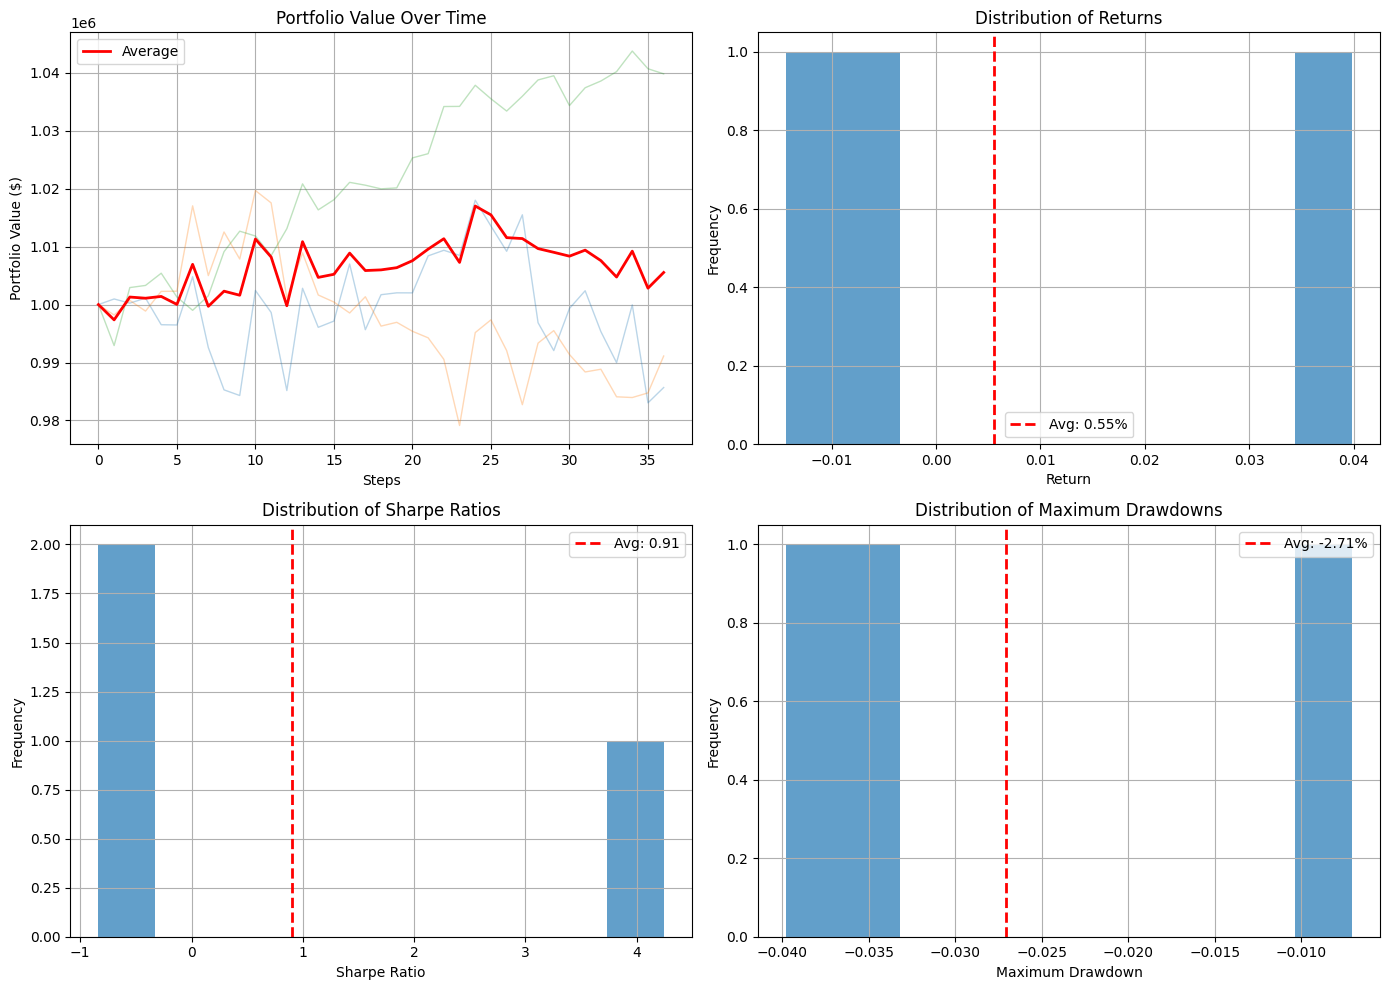


Low Risk Portfolio Recommendations:
       ticker  allocation_pct risk_category  sharpe_ratio
553    HMP.TO       19.593030           Low      0.485449
49     PET.TO       19.545813        Medium     -0.096106
229    FHQ.TO       19.539380        Medium      0.909682
513    ZXM.TO       19.511452        Medium      0.444116
1303  CPLS.TO       19.499394           Low     -0.263462
504    QCN.TO       19.496040        Medium      0.734113
447   QQEQ.TO       19.487016           Low      0.599966
1146  XCHP.TO       19.486163           Low      0.450342
351    CAS.TO       19.475677          High      0.256616
122    ZIN.TO       19.466926        Medium      0.667707

Medium Risk Portfolio Recommendations:
       ticker  allocation_pct risk_category  sharpe_ratio
553    WCP.TO       19.593030          High      0.523016
49    IGAF.TO       19.545813        Medium      0.294888
229   RGQS.TO       19.539380           Low      1.241331
513      E.TO       19.511452          High      0.42

In [22]:
def main():
    """Main execution function"""
    # Use the correct data file path
    file_path = "C:/Users/nikhi/Desktop/Capstone project/historical_data.csv"

    print(f"Using data file: {file_path}")

    # Process data with reduced minimum data requirement
    stock_dfs = prepare_stock_data(file_path, min_data_points=60)

    if len(stock_dfs) == 0:
        print("No valid stock data found. Cannot continue.")
        return

    # Calculate risk metrics
    risk_df = calculate_risk_metrics(stock_dfs, lookback_period=None)

    # Train SAC model with reduced training time
    try:
        # Use a smaller timestep for faster training
        total_timesteps = 10000  # Further reduced for faster training

        model, env, feature_columns = train_sac_model(stock_dfs, risk_df, total_timesteps=total_timesteps)

        # Save trained model
        model.save("sac_portfolio_risk_model")
        print("Model saved successfully")

        # Evaluate model
        eval_results = evaluate_sac_model(model, stock_dfs, risk_df, feature_columns, n_episodes=3)

        # Visualize results
        visualize_portfolio_performance(eval_results)

        # Generate recommendations for different risk profiles
        for risk_profile in ['Low', 'Medium', 'High']:
            recommendations = generate_portfolio_recommendations(
                model, stock_dfs, risk_df, feature_columns, risk_profile=risk_profile
            )

            print(f"\n{risk_profile} Risk Portfolio Recommendations:")
            if not recommendations.empty:
                display_cols = [col for col in ['ticker', 'allocation_pct', 'risk_category', 'sharpe_ratio']
                               if col in recommendations.columns]
                print(recommendations[display_cols].head(10))

                # Save recommendations to CSV
                recommendations.to_csv(f"{risk_profile.lower()}_risk_portfolio_recommendations.csv", index=False)
            else:
                print("No recommendations generated")

    except Exception as e:
        print(f"Error in SAC model processing: {str(e)}")
        import traceback
        traceback.print_exc()
        print("Falling back to traditional risk classification only")

        # Print the available risk classifications as fallback
        if not risk_df.empty:
            print("\nRisk Classification Results:")
            display_cols = [col for col in ['ticker', 'risk_category', 'risk_score', 'volatility', 'max_drawdown']
                           if col in risk_df.columns]
            print(risk_df[display_cols].head(20))
            risk_df.to_csv("stock_risk_classification.csv", index=False)

if __name__ == "__main__":
    main()

In [28]:
import pickle
import os

def save_model_pickle(model, filepath="sac_portfolio_model.pkl"):
    """
    Simply saves the model as a pickle file
    
    Args:
        model: The trained SAC model
        filepath: Path where to save the pickle file
    """
    # Create directory if needed
    directory = os.path.dirname(filepath)
    if directory and not os.path.exists(directory):
        os.makedirs(directory)
        
    # Save the model using pickle
    with open(filepath, 'wb') as f:
        pickle.dump(train_sac_model, f)
    
    print(f"Model saved to {filepath}")

# Add this to your main function
if __name__ == "__main__":
    '''# Your existing code...
    
    # After training the model
    model, env, feature_columns = train_sac_model()'''
    
    # Save the model
    save_model_pickle(train_sac_model)
    

Model saved to sac_portfolio_model.pkl


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def backtest_summary(model, env, num_episodes=1):
    """
    Run the SAC model in the environment and print a backtest summary.
    Shows cumulative rewards, action distributions, and simple plots.
    """
    all_rewards = []
    all_actions = []
    all_episode_lengths = []

    for episode in range(num_episodes):
        obs = env.reset()
        done = False
        total_reward = 0
        episode_length = 0
        actions = []

        while not done:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            total_reward += reward
            episode_length += 1
            actions.append(action)

        all_rewards.append(total_reward)
        all_actions.extend(actions)
        all_episode_lengths.append(episode_length)

        print(f"Episode {episode+1} → Total Reward: {total_reward:.2f} | Length: {episode_length} steps")

    # Summary Statistics
    print("\n🔍 Backtest Summary:")
    print(f"Average Reward: {np.mean(all_rewards):.2f}")
    print(f"Max Reward: {np.max(all_rewards):.2f}")
    print(f"Min Reward: {np.min(all_rewards):.2f}")
    print(f"Average Episode Length: {np.mean(all_episode_lengths):.2f}")

    # Action distribution
    all_actions = np.array(all_actions)
    plt.figure(figsize=(10, 4))
    plt.hist(all_actions, bins=30, edgecolor='black')
    plt.title('Distribution of Actions Taken')
    plt.xlabel('Action Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


In [35]:
import optuna
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

def optimize_sac(trial):
    # Sample hyperparameters
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-3)
    buffer_size = trial.suggest_categorical('buffer_size', [50000, 100000, 200000])
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    tau = trial.suggest_uniform('tau', 0.005, 0.05)
    gamma = trial.suggest_uniform('gamma', 0.9, 0.9999)
    net_arch = trial.suggest_categorical("net_arch", [[256, 256], [400, 300], [512, 512]])

    policy_kwargs = dict(net_arch=net_arch)

    # Environment setup
    env = make_vec_env('Pendulum-v1', n_envs=1)

    # Train model
    model = SAC('MlpPolicy', env, learning_rate=learning_rate, buffer_size=buffer_size,
                batch_size=batch_size, tau=tau, gamma=gamma,
                policy_kwargs=policy_kwargs, verbose=0)

    model.learn(total_timesteps=5000)

    # Evaluate model
    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=5)
    return mean_reward

# Create the study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(optimize_sac, n_trials=20)

# Best parameters
print("Best hyperparameters:", study.best_params)


C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\
Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. 
See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\
Python312\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[I 2025-04-07 21:25:34,541] A new study created in memory with name: no-name-63cb91ea-f550-4e30-ad92-d7385dfc55bc

C:\Users\nikhi\AppData\Local\Temp\ipykernel_26952\2523031014.py:8: FutureWarning: suggest_loguniform has been 
deprecated in v3.0.0. This feature will be removed in v6.0.0. See 
https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-3)

C:\Users\nikhi\AppData\Local\Temp\ipykernel_26952\2523031014.py:11: FutureWarning: suggest_uniform has been 
deprecated in v3.0.0. This feature will be removed in v6.0.0. See 
https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  tau = trial.suggest_uniform('tau', 0.005, 0.05)

...

C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\
Python312\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be 
a tuple of None, bool, int, float and str for persistent storage but contains [512, 512] which is of type list.
  warnings.warn(message)

[I 2025-04-07 21:33:54,785] Trial 0 finished with value: -240.17984840000003 and parameters: {'learning_rate': 
0.000912003560389415, 'buffer_size': 50000, 'batch_size': 128, 'tau': 0.033253336741790186, 'gamma': 
0.9057618485418696, 'net_arch': [400, 300]}. Best is trial 0 with value: -240.17984840000003.

[W 2025-04-07 21:40:33,720] Trial 1 failed with parameters: {'learning_rate': 8.74857671947024e-05, 'buffer_size': 
50000, 'batch_size': 64, 'tau': 0.027543944321787316, 'gamma': 0.9725811702284414, 'net_arch': [512, 512]} because 
of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\nikhi\AppData\Local\Temp\ipykernel_26952\2523031014.py", line 25, in optimize_sac
    model.learn(total_timesteps=5000)
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\stable_baselines3\sac\sac.py", line 307, in learn
    return super().learn(
           ^^^^^^^^^^^^^^
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\stable_baselines3\common\off_policy_algorithm.py", line 347, in learn
    self.train(batch_size=self.batch_size, gradient_steps=gradient_steps)
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\stable_baselines3\sac\sac.py", line 243, in train
    self.ent_coef_optimizer.step()
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\torch\optim\optimizer.py", line 493, in wrapper
    out = func(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\torch\optim\optimizer.py", line 91, in _use_grad
    ret = func(self, *args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\torch\optim\adam.py", line 244, in step
    adam(
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\torch\optim\optimizer.py", line 154, in maybe_fallback
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\torch\optim\adam.py", line 876, in adam
    func(
  File 
"C:\Users\nikhi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages
\Python312\site-packages\torch\optim\adam.py", line 400, in _single_tensor_adam
    if torch.is_complex(param):
       ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt

[W 2025-04-07 21:40:33,815] Trial 1 failed with value None.

KeyboardInterrupt: 

### **BACK TEST** 

In [24]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import pickle
from stable_baselines3 import SAC
from collections import defaultdict
import json
from tqdm import tqdm

class PortfolioBacktester:
    """
    Class for backtesting portfolio allocation strategies using SAC models
    with historical market data - no visualization components
    """
    
    def __init__(self, stock_dfs, risk_df, feature_columns, initial_capital=1000000,
                transaction_fee=0.001, risk_free_rate=0.02):
        """
        Initialize the backtester
        
        Args:
            stock_dfs (dict): Dictionary of stock DataFrames with historical data
            risk_df (pd.DataFrame): DataFrame with risk metrics for stocks
            feature_columns (list): List of feature columns used in the model
            initial_capital (float): Initial capital for backtesting
            transaction_fee (float): Transaction fee as a percentage
            risk_free_rate (float): Annual risk-free rate
        """
        self.stock_dfs = stock_dfs
        self.risk_df = risk_df
        self.feature_columns = feature_columns
        self.initial_capital = initial_capital
        self.transaction_fee = transaction_fee
        self.risk_free_rate = risk_free_rate
        
        # Get all available dates across all stocks
        self.all_dates = self._get_all_dates()
        self.date_to_index = {date: i for i, date in enumerate(self.all_dates)}
        
        # Initialize output directory
        os.makedirs("backtest_results", exist_ok=True)
    
    def _get_all_dates(self):
        """Get sorted list of all unique dates in the dataset"""
        all_dates = set()
        for ticker, df in self.stock_dfs.items():
            if 'date' in df.columns:
                all_dates.update(df['date'].tolist())
        
        return sorted(list(all_dates))
    
    def _get_aligned_dates(self, start_date, end_date):
        """Get a list of dates within the specified range"""
        # Filter dates within range
        valid_dates = [date for date in self.all_dates 
                      if start_date <= date <= end_date]
        return valid_dates
    
    def _get_price_on_date(self, ticker, date):
        """Get closing price for a stock on a specific date"""
        df = self.stock_dfs.get(ticker, None)
        if df is None:
            return None
        
        # Find the row for the date
        if 'date' in df.columns:
            date_data = df[df['date'] == date]
            if len(date_data) > 0:
                return date_data['close'].values[0]
        
        return None
    
    def _get_stock_data_window(self, ticker, end_date, window_size=20):
        """
        Get a window of historical data for a stock ending on a specific date
        
        Args:
            ticker (str): Stock ticker symbol
            end_date (datetime): End date of the window
            window_size (int): Number of days in the window
            
        Returns:
            pd.DataFrame: DataFrame with historical data
        """
        df = self.stock_dfs.get(ticker, None)
        if df is None:
            return None
        
        # Find index of end_date
        if 'date' in df.columns:
            end_idx = df[df['date'] <= end_date].index
            if len(end_idx) == 0:
                return None
            
            end_idx = end_idx[-1]
            
            # Get window of data
            start_idx = max(0, end_idx - window_size + 1)
            window_data = df.iloc[start_idx:end_idx+1].copy()
            
            return window_data
        
        return None
    
    def _calculate_portfolio_metrics(self, returns):
        """
        Calculate portfolio performance metrics
        
        Args:
            returns (list): Daily portfolio returns
            
        Returns:
            dict: Dictionary of performance metrics
        """
        returns = np.array(returns)
        
        # Remove NaNs
        returns = returns[~np.isnan(returns)]
        
        if len(returns) == 0:
            return {
                'total_return': 0,
                'annualized_return': 0,
                'volatility': 0,
                'sharpe_ratio': 0,
                'max_drawdown': 0,
                'win_rate': 0,
                'profit_factor': 0
            }
        
        # Calculate metrics
        total_return = np.prod(1 + returns) - 1
        annualized_return = (1 + total_return) ** (252 / len(returns)) - 1
        volatility = np.std(returns) * np.sqrt(252)
        
        # Sharpe ratio
        excess_returns = returns - self.risk_free_rate / 252  # Daily risk-free rate
        sharpe_ratio = (np.mean(excess_returns) * 252) / (np.std(excess_returns) * np.sqrt(252)) if np.std(excess_returns) > 0 else 0
        
        # Maximum drawdown
        cumulative = np.cumprod(1 + returns)
        peak = np.maximum.accumulate(cumulative)
        drawdown = (cumulative / peak) - 1
        max_drawdown = np.min(drawdown)
        
        # Win rate and profit factor
        win_rate = np.sum(returns > 0) / len(returns) if len(returns) > 0 else 0
        
        gains = np.sum(returns[returns > 0])
        losses = np.abs(np.sum(returns[returns < 0]))
        profit_factor = gains / losses if losses > 0 else float('inf')
        
        return {
            'total_return': total_return,
            'annualized_return': annualized_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'win_rate': win_rate,
            'profit_factor': profit_factor
        }
    
    def run_backtest(self, model, start_date, end_date, window_size=20, 
                    rebalance_frequency=5, risk_budget=1.0, max_position_size=0.2,
                    benchmark_tickers=None):
        """
        Run a backtest of the portfolio allocation strategy
        
        Args:
            model: Trained SAC model
            start_date (datetime): Start date for backtesting
            end_date (datetime): End date for backtesting
            window_size (int): Historical window size for feature generation
            rebalance_frequency (int): Number of days between portfolio rebalancing
            risk_budget (float): Risk budget multiplier
            max_position_size (float): Maximum allocation to single asset
            benchmark_tickers (list): List of tickers to use as benchmarks
            
        Returns:
            dict: Backtest results
        """
        print(f"Running backtest from {start_date} to {end_date}")
        
        # Get trading dates
        trading_dates = self._get_aligned_dates(start_date, end_date)
        
        if len(trading_dates) == 0:
            print("No trading dates found in the specified range")
            return None
        
        # Select stocks for this backtest (stocks with data throughout the period)
        valid_stocks = []
        for ticker, df in self.stock_dfs.items():
            if 'date' in df.columns:
                # Check if stock has data for a significant portion of the backtest period
                dates_in_range = df[df['date'].between(start_date, end_date)]
                if len(dates_in_range) >= len(trading_dates) * 0.8:  # At least 80% coverage
                    valid_stocks.append(ticker)
        
        if len(valid_stocks) == 0:
            print("No valid stocks found with sufficient data in the specified range")
            return None
        
        print(f"Using {len(valid_stocks)} stocks for backtest")
        
        # Initialize portfolio
        portfolio = {
            'cash': self.initial_capital,
            'positions': {ticker: 0 for ticker in valid_stocks},
            'position_values': {ticker: 0 for ticker in valid_stocks},
            'history': []
        }
        
        # Initialize portfolio metrics tracking
        portfolio_values = []
        portfolio_returns = []
        positions_history = []
        allocation_history = []
        trades_history = []
        
        # Initialize benchmark tracking
        benchmark_values = {ticker: [] for ticker in (benchmark_tickers or [])}
        benchmark_starting_prices = {}
        
        # Get the environment observation generator
        env_obs_generator = self._create_observation_generator(window_size, max_position_size)
        
        # Track last rebalance date
        last_rebalance_idx = -1
        
        # Run backtest day by day
        for date_idx, current_date in enumerate(tqdm(trading_dates)):
            # Update portfolio value at current date
            self._update_portfolio_values(portfolio, current_date)
            
            # Calculate total portfolio value
            total_value = portfolio['cash'] + sum(portfolio['position_values'].values())
            portfolio_values.append(total_value)
            
            # Calculate portfolio return
            if date_idx > 0:
                daily_return = (total_value / portfolio_values[-2]) - 1
            else:
                daily_return = 0
            
            portfolio_returns.append(daily_return)
            
            # Save portfolio state
            portfolio_snapshot = {
                'date': current_date,
                'total_value': total_value,
                'cash': portfolio['cash'],
                'positions': portfolio['positions'].copy(),
                'position_values': portfolio['position_values'].copy(),
                'daily_return': daily_return
            }
            portfolio['history'].append(portfolio_snapshot)
            
            # Save positions and allocations
            current_positions = {ticker: shares for ticker, shares in portfolio['positions'].items() if shares > 0}
            positions_history.append(current_positions)
            
            current_allocations = {}
            for ticker, value in portfolio['position_values'].items():
                if total_value > 0:
                    current_allocations[ticker] = value / total_value
                else:
                    current_allocations[ticker] = 0
            
            allocation_history.append(current_allocations)
            
            # Update benchmark values
            for ticker in benchmark_tickers or []:
                price = self._get_price_on_date(ticker, current_date)
                if price is not None:
                    if ticker not in benchmark_starting_prices:
                        benchmark_starting_prices[ticker] = price
                        benchmark_values[ticker].append(self.initial_capital)
                    else:
                        relative_price = price / benchmark_starting_prices[ticker]
                        benchmark_values[ticker].append(self.initial_capital * relative_price)
            
            # Check if rebalancing is needed
            if date_idx - last_rebalance_idx >= rebalance_frequency:
                # Generate observation for the model
                observation = env_obs_generator(portfolio, valid_stocks, current_date, total_value)
                
                if observation is not None:
                    # Get model prediction (action)
                    action, _ = model.predict(observation, deterministic=True)
                    
                    # First action controls risk budget, remaining actions control stock allocations
                    model_risk_budget = 1.0 + (action[0] * 0.5)  # Scale to range [0.5, 1.5]
                    actual_risk_budget = model_risk_budget * risk_budget  # Apply user risk budget modifier
                    
                    stock_actions = action[1:len(valid_stocks)+1]
                    
                    # Execute trades
                    trades = self._execute_model_trades(
                        portfolio, 
                        valid_stocks, 
                        stock_actions, 
                        current_date, 
                        actual_risk_budget, 
                        max_position_size
                    )
                    
                    # Record trades
                    if trades:
                        trade_record = {
                            'date': current_date,
                            'trades': trades,
                            'risk_budget': actual_risk_budget
                        }
                        trades_history.append(trade_record)
                    
                    last_rebalance_idx = date_idx
        
        # Calculate final portfolio performance metrics
        performance_metrics = self._calculate_portfolio_metrics(portfolio_returns)
        
        # Calculate benchmark performance
        benchmark_metrics = {}
        for ticker in benchmark_tickers or []:
            if ticker in benchmark_values and len(benchmark_values[ticker]) > 0:
                # Calculate benchmark returns
                benchmark_returns = []
                for i in range(1, len(benchmark_values[ticker])):
                    daily_return = (benchmark_values[ticker][i] / benchmark_values[ticker][i-1]) - 1
                    benchmark_returns.append(daily_return)
                
                # Calculate metrics
                benchmark_metrics[ticker] = self._calculate_portfolio_metrics(benchmark_returns)
        
        # Calculate turnover
        total_trades_value = 0
        for trade in trades_history:
            for ticker, trade_info in trade['trades'].items():
                total_trades_value += abs(trade_info['value'])
        
        avg_portfolio_value = np.mean(portfolio_values) if portfolio_values else self.initial_capital
        turnover = total_trades_value / (2 * avg_portfolio_value)  # Divide by 2 to avoid double counting
        
        # Prepare results
        results = {
            'initial_capital': self.initial_capital,
            'final_value': portfolio_values[-1] if portfolio_values else self.initial_capital,
            'performance_metrics': performance_metrics,
            'dates': trading_dates,
            'portfolio_values': portfolio_values,
            'portfolio_returns': portfolio_returns,
            'positions_history': positions_history,
            'allocation_history': allocation_history,
            'trades_history': trades_history,
            'benchmark_values': benchmark_values,
            'benchmark_metrics': benchmark_metrics,
            'portfolio_history': portfolio['history'],
            'turnover': turnover,
            'rebalance_frequency': rebalance_frequency,
            'risk_budget': risk_budget,
            'max_position_size': max_position_size
        }
        
        # Print summary
        self._print_backtest_summary(results, benchmark_tickers)
        
        # Save results to file
        results_file = f"backtest_results/backtest_{start_date.strftime('%Y%m%d')}_{end_date.strftime('%Y%m%d')}.json"
        self._save_results(results, results_file)
        
        return results
    
    def _update_portfolio_values(self, portfolio, current_date):
        """Update the value of all positions based on current prices"""
        for ticker in portfolio['positions']:
            current_price = self._get_price_on_date(ticker, current_date)
            if current_price is not None and current_price > 0:
                portfolio['position_values'][ticker] = portfolio['positions'][ticker] * current_price
    
    def _execute_model_trades(self, portfolio, valid_stocks, stock_actions, 
                             current_date, risk_budget, max_position_size):
        """Execute trades based on model actions"""
        # Current portfolio value
        current_portfolio_value = portfolio['cash'] + sum(portfolio['position_values'].values())
        
        # Apply risk budget to actions
        risk_weighted_actions = stock_actions * risk_budget
        
        # Calculate target values for each position
        target_values = {}
        for i, ticker in enumerate(valid_stocks):
            if i < len(risk_weighted_actions):
                # Convert action to target position size (% of portfolio)
                action = risk_weighted_actions[i]
                target_allocation = (action + 1) / 2 * max_position_size
                target_values[ticker] = target_allocation * current_portfolio_value
            else:
                target_values[ticker] = 0
        
        # Track trades
        trades = {}
        
        # Execute trades to achieve target values
        for ticker in valid_stocks:
            current_price = self._get_price_on_date(ticker, current_date)
            
            # Skip if price data is missing
            if current_price is None or current_price <= 0:
                continue
            
            current_value = portfolio['position_values'].get(ticker, 0)
            target_value = target_values.get(ticker, 0)
            
            # Calculate shares to trade
            value_difference = target_value - current_value
            shares_to_trade = value_difference / current_price
            
            # Calculate transaction fee
            transaction_fee = abs(value_difference) * self.transaction_fee
            
            # Execute trade if it's significant enough (>0.1% of portfolio)
            if abs(value_difference) > current_portfolio_value * 0.001:
                if shares_to_trade > 0:  # Buy
                    cost = value_difference + transaction_fee
                    if portfolio['cash'] >= cost:
                        portfolio['positions'][ticker] = portfolio['positions'].get(ticker, 0) + shares_to_trade
                        portfolio['position_values'][ticker] = current_value + value_difference
                        portfolio['cash'] -= cost
                        
                        # Record trade
                        trades[ticker] = {
                            'action': 'buy',
                            'shares': shares_to_trade,
                            'price': current_price,
                            'value': value_difference,
                            'fee': transaction_fee
                        }
                else:  # Sell
                    proceeds = -value_difference - transaction_fee
                    current_shares = portfolio['positions'].get(ticker, 0)
                    if current_shares >= abs(shares_to_trade):
                        portfolio['positions'][ticker] = current_shares - abs(shares_to_trade)
                        portfolio['position_values'][ticker] = current_value - abs(value_difference)
                        portfolio['cash'] += proceeds
                        
                        # Record trade
                        trades[ticker] = {
                            'action': 'sell',
                            'shares': abs(shares_to_trade),
                            'price': current_price,
                            'value': -value_difference,
                            'fee': transaction_fee
                        }
        
        return trades
    
    def _create_observation_generator(self, window_size, max_position_size):
        """Create a function that generates observations for the model"""
        
        def generate_observation(portfolio, valid_stocks, current_date, total_portfolio_value):
            """
            Generate an observation vector for the model
            
            Args:
                portfolio (dict): Current portfolio state
                valid_stocks (list): List of valid stock tickers
                current_date (datetime): Current date
                total_portfolio_value (float): Total portfolio value
                
            Returns:
                numpy.ndarray: Observation vector
            """
            observations = []
            
            # For each stock in the portfolio
            for ticker in valid_stocks:
                stock_features = []
                
                # Get historical window of data
                window_data = self._get_stock_data_window(ticker, current_date, window_size)
                
                if window_data is None or len(window_data) < window_size * 0.8:  # Need at least 80% of window data
                    # If we don't have valid data, add zeros
                    flat_features = np.zeros(len(self.feature_columns) * 5)
                    stock_features.extend(flat_features)
                else:
                    # Extract features
                    for col in self.feature_columns:
                        if col in window_data.columns:
                            values = window_data[col].values
                            
                            # Replace NaN and Inf values
                            values = np.nan_to_num(values, nan=0.0, posinf=10.0, neginf=-10.0)
                            
                            if len(values) > 0:
                                feature_mean = np.mean(values)
                                feature_std = np.std(values)
                                feature_min = np.min(values)
                                feature_max = np.max(values)
                                feature_last = values[-1]
                            else:
                                feature_mean = feature_std = feature_min = feature_max = feature_last = 0.0
                            
                            # Normalize features
                            feature_mean = np.clip(feature_mean, -10.0, 10.0)
                            feature_std = np.clip(feature_std, 0.0, 10.0)
                            feature_min = np.clip(feature_min, -10.0, 10.0)
                            feature_max = np.clip(feature_max, -10.0, 10.0)
                            feature_last = np.clip(feature_last, -10.0, 10.0)
                            
                            stock_features.extend([feature_mean, feature_std, feature_min, feature_max, feature_last])
                        else:
                            # Pad with zeros if feature not available
                            stock_features.extend([0.0, 0.0, 0.0, 0.0, 0.0])
                
                # Add risk information
                if ticker in self.risk_df['ticker'].values:
                    risk_info = self.risk_df[self.risk_df['ticker'] == ticker].iloc[0]
                    risk_score = risk_info['risk_score']
                    volatility = risk_info['volatility']
                    sharpe = risk_info['sharpe_ratio']
                else:
                    risk_score = 0.5  # Medium risk if not found
                    volatility = 0.2  # Moderate volatility
                    sharpe = 0.0  # Neutral Sharpe ratio
                
                stock_features.extend([risk_score, volatility, sharpe])
                
                # Add position information
                current_price = self._get_price_on_date(ticker, current_date)
                position_size = portfolio['positions'].get(ticker, 0)
                position_value = position_size * (current_price or 0)
                allocation = position_value / total_portfolio_value if total_portfolio_value > 0 else 0
                
                stock_features.extend([position_size, position_value, allocation])
                
                observations.extend(stock_features)
            
            # Add portfolio-level features
            portfolio_features = [
                portfolio['cash'] / self.initial_capital,  # Normalized cash
                total_portfolio_value / self.initial_capital,  # Normalized portfolio value
                1.0,  # Default risk budget
                len([t for t in portfolio['positions'] if portfolio['positions'][t] > 0]) / len(valid_stocks),  # Portfolio diversification
                0.5  # Middle of episode
            ]
            
            # Add dummy values for recent portfolio performance
            portfolio_features.extend([0.0, 0.0, 0.0, 0.0, 0.0])
            
            observations.extend(portfolio_features)
            
            # Ensure fixed length of the observation vector
            expected_length = len(valid_stocks) * len(self.feature_columns) * 5 + 10
            
            if len(observations) < expected_length:
                padding = [0.0] * (expected_length - len(observations))
                observations.extend(padding)
            elif len(observations) > expected_length:
                observations = observations[:expected_length]
            
            # Final check for NaN/Inf values
            observations = np.array(observations, dtype=np.float32)
            observations = np.nan_to_num(observations, nan=0.0, posinf=10.0, neginf=-10.0)
            
            return observations
        
        return generate_observation
    
    def _print_backtest_summary(self, results, benchmark_tickers):
        """Print a summary of backtest results"""
        print("\n" + "="*50)
        print(f"BACKTEST SUMMARY ({results['dates'][0]} to {results['dates'][-1]})")
        print("="*50)
        
        # Portfolio performance
        metrics = results['performance_metrics']
        print(f"Initial Capital: ${results['initial_capital']:,.2f}")
        print(f"Final Value: ${results['final_value']:,.2f}")
        print(f"Total Return: {metrics['total_return']:.2%}")
        print(f"Annualized Return: {metrics['annualized_return']:.2%}")
        print(f"Volatility: {metrics['volatility']:.2%}")
        print(f"Sharpe Ratio: {metrics['sharpe_ratio']:.2f}")
        print(f"Maximum Drawdown: {metrics['max_drawdown']:.2%}")
        print(f"Win Rate: {metrics['win_rate']:.2%}")
        print(f"Profit Factor: {metrics['profit_factor']:.2f}")
        print(f"Turnover: {results['turnover']:.2f}")
        
        # Benchmark comparison
        if benchmark_tickers:
            print("\nBenchmark Comparison:")
            for ticker in benchmark_tickers:
                if ticker in results['benchmark_metrics']:
                    bmk = results['benchmark_metrics'][ticker]
                    print(f"\n{ticker}:")
                    print(f"  Total Return: {bmk['total_return']:.2%}")
                    print(f"  Annualized Return: {bmk['annualized_return']:.2%}")
                    print(f"  Sharpe Ratio: {bmk['sharpe_ratio']:.2f}")
                    
                    # Calculate outperformance
                    outperformance = metrics['annualized_return'] - bmk['annualized_return']
                    print(f"  Portfolio Outperformance: {outperformance:.2%}")
        
        # Final portfolio allocation
        print("\nFinal Portfolio Allocation:")
        final_allocations = results['allocation_history'][-1] if results['allocation_history'] else {}
        
        # Sort allocations by value
        sorted_allocations = sorted(final_allocations.items(), key=lambda x: x[1], reverse=True)
        
        # Print top 10 positions
        for ticker, allocation in sorted_allocations[:10]:
            if allocation > 0.01:  # Only show positions above 1%
                print(f"  {ticker}: {allocation:.2%}")
        
        # Trade statistics
        print("\nTrade Statistics:")
        num_trades = sum(len(trade['trades']) for trade in results['trades_history'])
        print(f"  Total Trades: {num_trades}")
        print(f"  Average Trades per Rebalance: {num_trades / len(results['trades_history']):.2f}" if results['trades_history'] else "  No trades executed")
        
        print("="*50)
    
    def _save_results(self, results, file_path):
        """Save backtest results to a file"""
        # Convert complex objects to serializable format
        serializable_results = {
            'initial_capital': results['initial_capital'],
            'final_value': results['final_value'],
            'performance_metrics': results['performance_metrics'],
            'dates': [date.strftime('%Y-%m-%d') for date in results['dates']],
            'portfolio_values': results['portfolio_values'],
            'portfolio_returns': [float(r) for r in results['portfolio_returns']],
            'turnover': results['turnover'],
            'rebalance_frequency': results['rebalance_frequency'],
            'risk_budget': results['risk_budget'],
            'max_position_size': results['max_position_size'],
            'benchmark_metrics': results['benchmark_metrics']
        }
        
        # Save to JSON file
        with open(file_path, 'w') as f:
            json.dump(serializable_results, f, indent=4)
        
        print(f"Results saved to {file_path}")
        
        # Save detailed data to CSV for further analysis
        csv_path = file_path.replace('.json', '.csv')
        
        # Create a DataFrame with daily data
        daily_data = []
        for i, date in enumerate(results['dates']):
            row = {
                'date': date.strftime('%Y-%m-%d'),
                'portfolio_value': results['portfolio_values'][i],
                'daily_return': results['portfolio_returns'][i] if i < len(results['portfolio_returns']) else None
            }
            
            # Add benchmark values
            for ticker, values in results['benchmark_values'].items():
                if i < len(values):
                    row[f'{ticker}_value'] = values[i]
            
            daily_data.append(row)
        
        # Save to CSV
        pd.DataFrame(daily_data).to_csv(csv_path, index=False)
        print(f"Daily data saved to {csv_path}")
    
    def run_multi_period_backtest(self, model, full_start_date, full_end_date, 
                                 period_length=90, period_overlap=0, 
                                 **backtest_params):
        """
        Run multiple backtest periods to assess model stability across time
        
        Args:
            model: Trained SAC model
            full_start_date (datetime): Start date for the entire backtest range
            full_end_date (datetime): End date for the entire backtest range
            period_length (int): Length of each backtest period in days
            period_overlap (int): Number of days to overlap between periods
            **backtest_params: Additional parameters for run_backtest
            
        Returns:
            dict: Backtest results for each period
        """
        print(f"Running multi-period backtest from {full_start_date} to {full_end_date}")
        
        # Get all trading dates in the full range
        all_trading_dates = self._get_aligned_dates(full_start_date, full_end_date)
        
        if len(all_trading_dates) == 0:
            print("No trading dates found in the specified range")
            return None
        
        # Calculate period start and end dates
        period_results = []
        
        # Calculate step size
        step = period_length - period_overlap
        
        # Generate periods
        for i in range(0, len(all_trading_dates) - period_length + 1, step):
            period_start = all_trading_dates[i]
            period_end = all_trading_dates[i + period_length - 1]
            
            print(f"\nRunning period {len(period_results) + 1}: {period_start} to {period_end}")
            
            # Run backtest for this period
            result = self.run_backtest(model, period_start, period_end, **backtest_params)
            
            if result:
                period_results.append({
                    'start_date': period_start,
                    'end_date': period_end,
                    'results': result
                })
        
        # Calculate aggregate stats across periods
        if period_results:
            all_returns = [p['results']['performance_metrics']['annualized_return'] for p in period_results]
            all_sharpe = [p['results']['performance_metrics']['sharpe_ratio'] for p in period_results]
            all_drawdowns = [p['results']['performance_metrics']['max_drawdown'] for p in period_results]
            all_turnover = [p['results']['turnover'] for p in period_results]
            
            aggregate_stats = {
                'avg_annualized_return': np.mean(all

SyntaxError: incomplete input (3603615433.py, line 728)